In [26]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from plotnine import (
    ggplot,
    aes,
    geom_col,
    coord_flip,
    labs,
    theme_bw,
    theme,
    element_text
)

## data path


In [4]:
#check current working directory
print(Path.cwd())

#set data path 
data_path = Path("../data/raw/hvca_ec.h5ad")
print(data_path)

/Users/FV/Documents/Personal/work/CV/portfolio/hvca-endothelial-reanalysis/analysis
../data/raw/hvca_ec.h5ad


## loading data

I start from the processed endothelial-cell object. I am not reprocessing raw data here because the goal is to inspect the published annotations and metadata structure, not to reproduce the full atlas workflow.

In [5]:
#checking data existance
data = sc.read_h5ad(data_path)
print(data)

#checking data dimensions
print("Cells:", data.n_obs)
print("Genes:", data.n_vars)

AnnData object with n_obs × n_vars = 34433 × 30021
    obs: 'donor', 'kit', 'study', 'organ_uni', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'sex', 'scrublet_score', 'doublet_bh_pval', 'broad_celltype', 'art_ven', 'cap', 'ann_ec_states', 'sample_id', 'age_groups', 'dataset', 'dataset_group'
    var: 'mt', 'rb', 'highly_variable', 'ENSG_id-1'
    uns: 'ann_ec_states_colors', 'art_ven_colors', 'cap_colors'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
Cells: 34433
Genes: 30021


## Metadata and annotation columns

The object is already filtered to endothelial cells, so I use the existing annotations provided with the dataset.

For this analysis, I use:

- `organ_uni` as the organ/tissue label
- `art_ven` as the broad endothelial compartment label
- `cap` as the capillary-related label
- `ann_ec_states` as the endothelial-state annotation
- `donor`, `sample_id`, `study`, and `dataset` to keep track of where cells come from

In [6]:
#inspecting metadata
data.obs.head()

,donor,kit,study,organ_uni,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,...,scrublet_score,doublet_bh_pval,broad_celltype,art_ven,cap,ann_ec_states,sample_id,age_groups,dataset,dataset_group
ctrl12_ATTCCTACAGGGCTTC-0,CTRL12,10x3prime_v3,Winkler_et_al_2022,brain,5780,8.662332,21583.0,9.979708,451.0,6.113682,...,NaN,NaN,NaN,cap_ec,blood_brain_barrier_ec,blood_brain_barrier_ec,CTRL12,nan,Winkler_2022,Nowakowski_lab
ctrl12_TTCAGGAGTTGGGTTT-0,CTRL12,10x3prime_v3,Winkler_et_al_2022,brain,6237,8.738415,23722.0,10.074200,698.0,6.549651,...,NaN,NaN,NaN,cap_ec,blood_brain_barrier_ec,blood_brain_barrier_ec,CTRL12,nan,Winkler_2022,Nowakowski_lab
ctrl12_CTAGACAGTTGCTAGT-0,CTRL12,10x3prime_v3,Winkler_et_al_2022,brain,5178,8.552367,16543.0,9.713779,168.0,5.129899,...,NaN,NaN,NaN,cap_ec,blood_brain_barrier_ec,blood_brain_barrier_ec,CTRL12,nan,Winkler_2022,Nowakowski_lab
ctrl12_GTTGTAGAGGTTCATC-0,CTRL12,10x3prime_v3,Winkler_et_al_2022,brain,5796,8.665096,18207.0,9.809616,180.0,5.198497,...,NaN,NaN,NaN,cap_ec,blood_brain_barrier_ec,blood_brain_barrier_ec,CTRL12,nan,Winkler_2022,Nowakowski_lab
ctrl12_GAAACCTCATCCCACT-0,CTRL12,10x3prime_v3,Winkler_et_al_2022,brain,4860,8.488999,15974.0,9.678780,267.0,5.590987,...,NaN,NaN,NaN,cap_ec,blood_brain_barrier_ec,blood_brain_barrier_ec,CTRL12,nan,Winkler_2022,Nowakowski_lab


In [7]:
#inspecting colnames
list(data.obs.columns)

['donor',
 'kit',
 'study',
 'organ_uni',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'total_counts_mt',
 'log1p_total_counts_mt',
 'pct_counts_mt',
 'total_counts_rb',
 'pct_counts_rb',
 'sex',
 'scrublet_score',
 'doublet_bh_pval',
 'broad_celltype',
 'art_ven',
 'cap',
 'ann_ec_states',
 'sample_id',
 'age_groups',
 'dataset',
 'dataset_group']

In [8]:
#inspecting obsm keys
list(data.obsm.keys())

['X_scVI',
 'X_umap',
 '_scvi_extra_categorical_covs',
 '_scvi_extra_continuous_covs']

In [9]:
#defining metadata columns used for analysis
organ_col = "organ_uni"
broad_state_col = "art_ven"
cap_col = "cap"
state_col = "ann_ec_states"

donor_col = "donor"
sample_col = "sample_id"
study_col = "study"
dataset_col = "dataset"
kit_col = "kit"
sex_col = "sex"
age_col = "age_groups"

key_cols = [
    organ_col,
    broad_state_col,
    cap_col,
    state_col,
    donor_col,
    sample_col,
    study_col,
    dataset_col,
    kit_col,
    sex_col,
    age_col,
]

### Missing metadata summary

Before using these columns, I check how much missing information they contain.

In [10]:
missing_summary = (
    data.obs[key_cols]
    .isna()
    .sum()
    .to_frame("n_missing"))

missing_summary["pct_missing"] = (missing_summary["n_missing"] / data.n_obs * 100).round(2)

missing_summary

,n_missing,pct_missing
organ_uni,0,0.00
art_ven,0,0.00
cap,0,0.00
ann_ec_states,0,0.00
donor,0,0.00
sample_id,0,0.00
study,0,0.00
dataset,0,0.00
kit,0,0.00
sex,952,2.76


No missing values besides sex. Nonetheless, for this project, it doesn't impair the analyses

## Cell counts by organ and annotation

I first count how many cells are present for each organ and annotation label. This is just to understand the dataset. A higher cell number, in the case of this dataset, here does not mean that the original tissue has more endothelial cells; it only means that more cells from that group are present in this processed object.

In [25]:
cell_counts_by_organ = (
    data.obs[organ_col]
    .value_counts(dropna=False)
    .rename_axis("organ")
    .reset_index(name="n_cells"))

cell_counts_by_broad_state = (
    data.obs[broad_state_col]
    .value_counts(dropna=False)
    .rename_axis("broad_state")
    .reset_index(name="n_cells"))

cell_counts_by_cap = (
    data.obs[cap_col]
    .value_counts(dropna=False)
    .rename_axis("cap_label")
    .reset_index(name="n_cells"))

cell_counts_by_state = (
    data.obs[state_col]
    .value_counts(dropna=False)
    .rename_axis("ec_state")
    .reset_index(name="n_cells"))

print(cell_counts_by_organ.head(5))
print(cell_counts_by_broad_state.head(5))
print(cell_counts_by_cap.head(5))
print(cell_counts_by_state.head(5))

        organ  n_cells
0       heart     6283
1        lung     5647
2      muscle     3936
3  lymph_node     2653
4       liver     2522
  broad_state  n_cells
0      cap_ec    23128
1    ven_ec_2     2522
2    art_ec_2     2215
3    ven_ec_1     2137
4  pul_ven_ec     1286
    cap_label  n_cells
0  myo_cap_ec     7842
1      ven_ec     6088
2      art_ec     5153
3      cap_ec     3334
4  pul_cap_ec     2277
     ec_state  n_cells
0  myo_cap_ec     7842
1      cap_ec     3334
2    ven_ec_2     2522
3  pul_cap_ec     2277
4    art_ec_2     2215


### Simple count plots

I plot the same counts to get a quick view of how the dataset is distributed across organs and annotation labels.

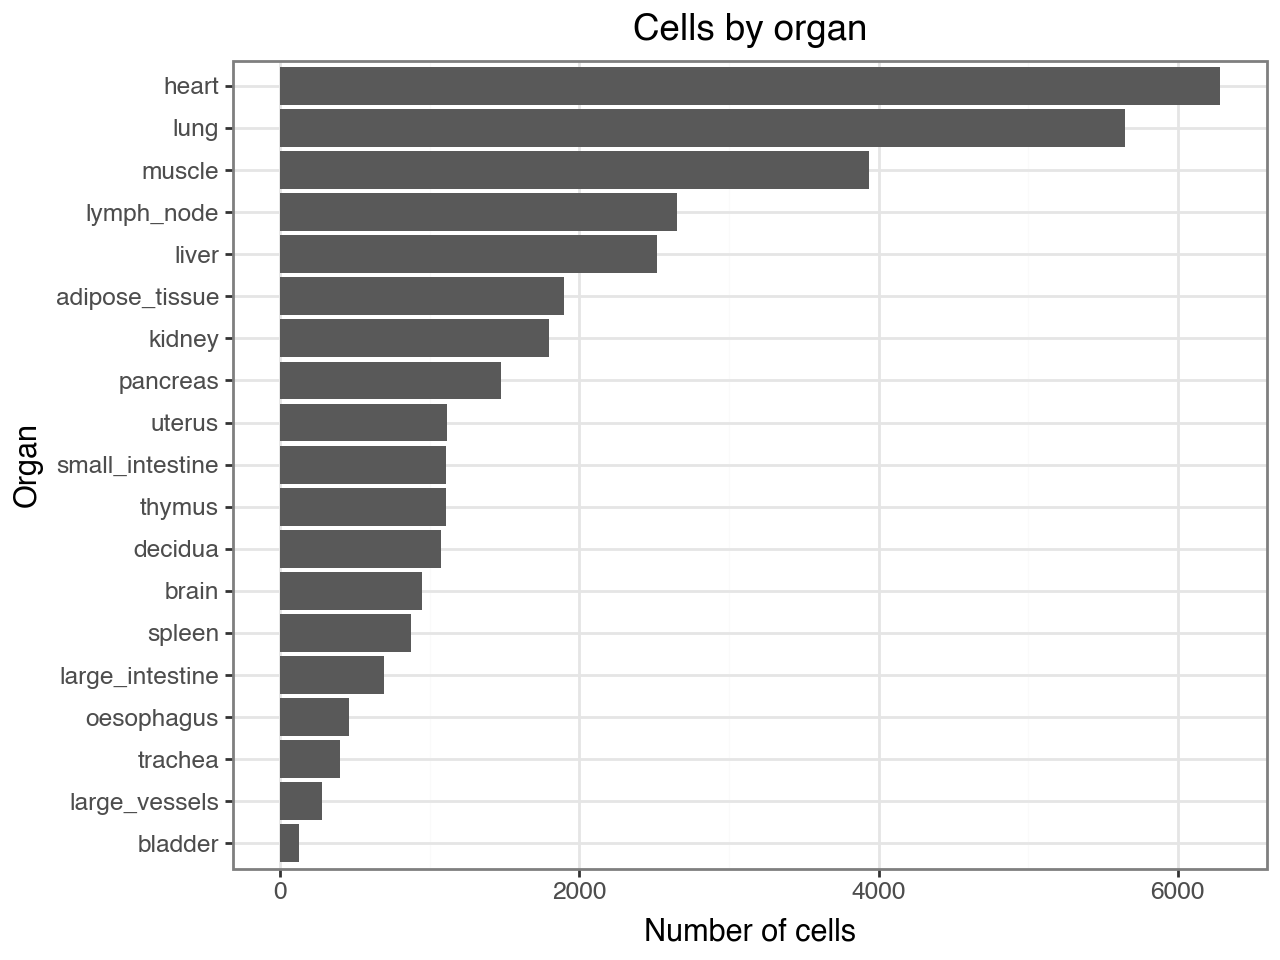

In [34]:
#plotting cell counts by organ
cell_counts_by_organ["organ"] = pd.Categorical(
    cell_counts_by_organ["organ"],
    categories=cell_counts_by_organ.sort_values("n_cells")["organ"],
    ordered=True)

(ggplot(cell_counts_by_organ, aes(x="reorder(organ, n_cells)", y="n_cells"))
    + geom_col()
    + coord_flip()
    + labs(
        x="Organ",
        y="Number of cells",
        title="Cells by organ"
    )
    + theme_bw())

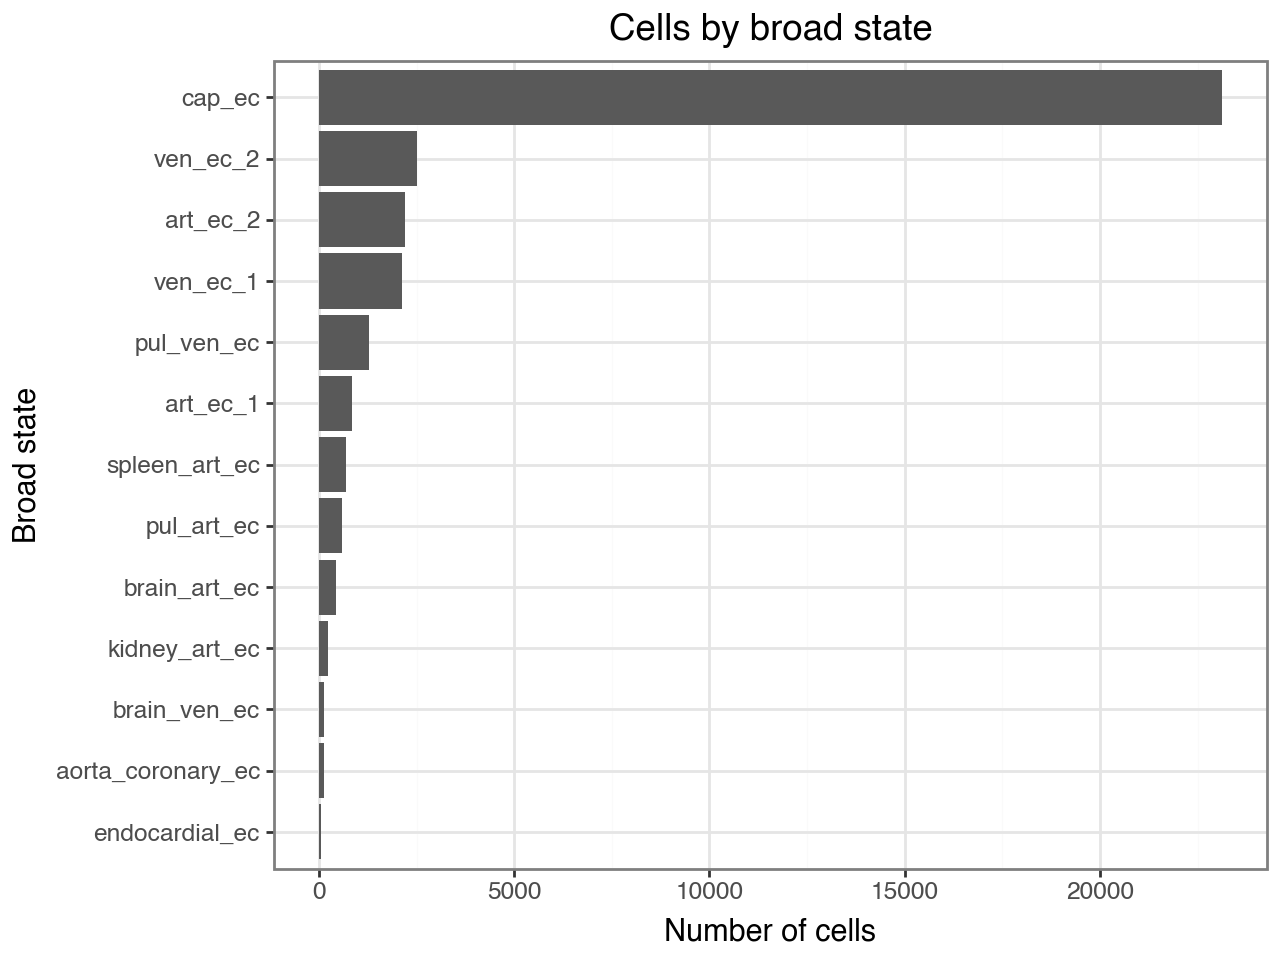

In [35]:
#plotting cell counts by broad state
cell_counts_by_broad_state["broad_state"] = pd.Categorical(
    cell_counts_by_broad_state["broad_state"],
    categories=cell_counts_by_broad_state.sort_values("n_cells")["broad_state"],
    ordered=True)               

(ggplot(cell_counts_by_broad_state, aes(x="reorder(broad_state, n_cells)", y="n_cells"))
    + geom_col()
    + coord_flip()
    + labs( 
        x="Broad state",
        y="Number of cells",
        title="Cells by broad state"
    )
    + theme_bw())

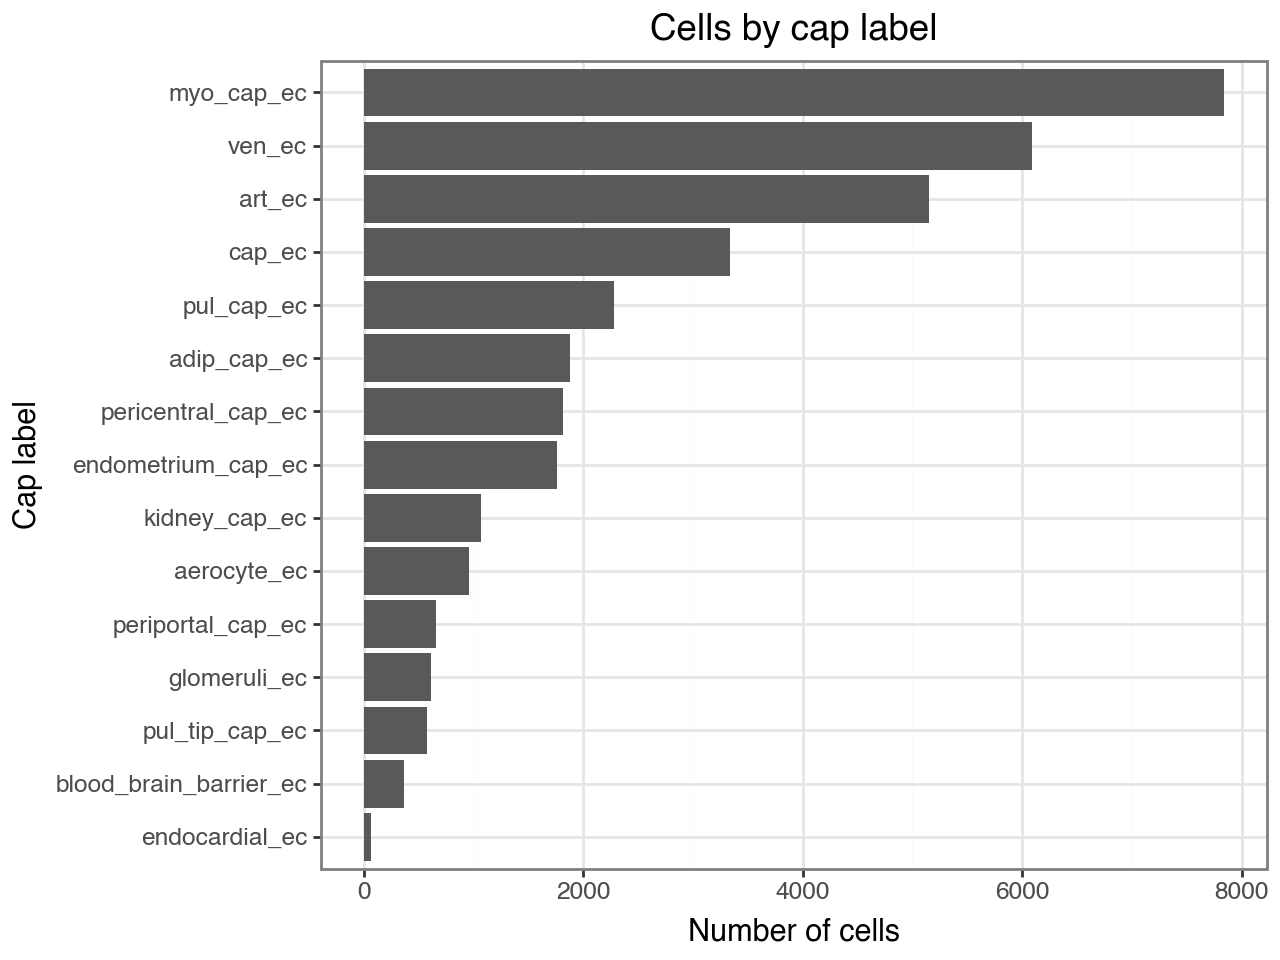

In [36]:
#plotting cell counts by cap
cell_counts_by_cap["cap_label"] = pd.Categorical(
    cell_counts_by_cap["cap_label"],
    categories=cell_counts_by_cap.sort_values("n_cells")["cap_label"],
    ordered=True)   

(ggplot(cell_counts_by_cap, aes(x="reorder(cap_label, n_cells)", y="n_cells"))
    + geom_col()
    + coord_flip() 
    + labs(
        x="Cap label",
        y="Number of cells",
        title="Cells by cap label"
    )
    + theme_bw())

The dataset is not evenly distributed across organs or annotation labels. This matters because large groups can dominate later visualizations, especially UMAPs and summary plots.